In [104]:
#importing libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

This cell imports necessary libraries for data manipulation, machine learning, and evaluation:
*   `pandas` and `numpy` are used for data handling.
*   `sklearn.model_selection.train_test_split` is for splitting data into training and testing sets.
*   `sklearn.preprocessing.StandardScaler` is for feature scaling.
*   `sklearn.linear_model.LogisticRegression` is for building the logistic regression model.
*   `sklearn.metrics.classification_report` and `confusion_matrix` are for evaluating the model's performance.

In [105]:
apps = pd.read_csv('application_record.csv')
credit = pd.read_csv('credit_record.csv')

In [106]:
df.shape # number of rows and columns shown

(36457, 19)

In [107]:
df.info() #information of whole data set

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36457 entries, 0 to 36456
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   36457 non-null  int64  
 1   CODE_GENDER          36457 non-null  object 
 2   FLAG_OWN_CAR         36457 non-null  object 
 3   FLAG_OWN_REALTY      36457 non-null  object 
 4   CNT_CHILDREN         36457 non-null  int64  
 5   AMT_INCOME_TOTAL     36457 non-null  float64
 6   NAME_INCOME_TYPE     36457 non-null  object 
 7   NAME_EDUCATION_TYPE  36457 non-null  object 
 8   NAME_FAMILY_STATUS   36457 non-null  object 
 9   NAME_HOUSING_TYPE    36457 non-null  object 
 10  DAYS_BIRTH           36457 non-null  int64  
 11  DAYS_EMPLOYED        36457 non-null  int64  
 12  FLAG_MOBIL           36457 non-null  int64  
 13  FLAG_WORK_PHONE      36457 non-null  int64  
 14  FLAG_PHONE           36457 non-null  int64  
 15  FLAG_EMAIL           36457 non-null 

data set of apps shown

In [108]:
apps

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
438552,6840104,M,N,Y,0,135000.0,Pensioner,Secondary / secondary special,Separated,House / apartment,-22717,365243,1,0,0,0,NaN,1.0
438553,6840222,F,N,N,0,103500.0,Working,Secondary / secondary special,Single / not married,House / apartment,-15939,-3007,1,0,0,0,Laborers,1.0
438554,6841878,F,N,N,0,54000.0,Commercial associate,Higher education,Single / not married,With parents,-8169,-372,1,1,0,0,Sales staff,1.0
438555,6842765,F,N,Y,0,72000.0,Pensioner,Secondary / secondary special,Married,House / apartment,-21673,365243,1,0,0,0,NaN,2.0


data set of credits shown

In [109]:
credit

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C
...,...,...,...
1048570,5150487,-25,C
1048571,5150487,-26,C
1048572,5150487,-27,C
1048573,5150487,-28,C


This cell loads two CSV files, 'application_record.csv' and 'credit_record.csv', into pandas DataFrames named `apps` and `credit` respectively. These DataFrames likely contain applicant information and credit history, which will be used for building a credit risk model.

In [110]:
# Identify records meeting the high-risk overdue threshold
credit['is_bad'] = credit['STATUS'].isin(['2','3','4','5']).astype(int)

#Roll up performance to flag anyone who has ever crossed into the high risk territory
labels = credit.groupby('ID')['is_bad'].max().reset_index()

#Transform to standard model targets 1 = good/approved, 0 = bad/rejected
labels['target']= 1 - labels['is_bad']
labels = labels.drop(columns=['is_bad'])


This cell processes the `credit` DataFrame to identify high-risk accounts:
*   It creates a new column `is_bad` in the `credit` DataFrame. A value of `1` indicates a high-risk overdue status (status codes '2', '3', '4', '5'), while `0` indicates otherwise.
*   It then aggregates this information by `ID` to create a `labels` DataFrame. For each `ID`, `is_bad` is `1` if the account ever had a high-risk status, and `0` otherwise.
*   Finally, it transforms the `is_bad` column into a `target` column where `1` represents a 'good' (approved) customer and `0` represents a 'bad' (rejected) customer, which is a standard format for classification problems. The original `is_bad` column is then dropped.

In [111]:
df = pd.merge(apps,labels,on='ID',how='inner')

This cell merges the `apps` DataFrame (containing applicant information) with the `labels` DataFrame (containing the credit risk target) based on the common 'ID' column. The `how='inner'` argument ensures that only records present in both DataFrames are included in the resulting `df` DataFrame.

In [112]:
#Identify data gaps across columns
df.isna().sum()

#Label unrecorded fields to preserve row count without introducting bias
df['OCCUPATION_TYPE'] = df['OCCUPATION_TYPE'].fillna('UNKNOWN')

#Drop any administrative duplicate rows on the primary key identifier
df=df.drop_duplicates(subset='ID')


This cell handles missing data and duplicates:
*   `df.isna().sum()` is used to inspect the number of missing values in each column.
*   It fills `NaN` values in the 'OCCUPATION_TYPE' column with 'UNKNOWN' to avoid dropping rows and to preserve data integrity, treating missing occupation types as a distinct category.
*   `df.drop_duplicates(subset='ID')` removes any duplicate rows based on the 'ID' column, ensuring that each applicant is represented only once.

In [113]:
#Isolate text features for transformation
categorical_cols = df.select_dtypes(['object']).columns

#Transform columns while dropping the first column variation to prevent collinearity
df_encoded = pd.get_dummies(df,columns=categorical_cols, drop_first=True)


This cell performs one-hot encoding on categorical features:
*   `df.select_dtypes(['object']).columns` identifies all columns with 'object' data type, which typically represent categorical features.
*   `pd.get_dummies(df, columns=categorical_cols, drop_first=True)` converts these categorical columns into numerical format using one-hot encoding. `drop_first=True` is used to prevent multicollinearity by dropping the first category in each one-hot encoded set.

In [114]:
# split the data and apply feature scaling
# DROP ADMINISTRATIVE KEYS AND LABEL COLUMNS FROM TRAINING INPUTS

x = df_encoded.drop(columns=['ID','target'])
y= df_encoded['target']

#Split datasets with startification to maintain identical target ratios across buckets

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

# 2. Scale the data (This creates x_train_scaled!)
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

This cell prepares the data for model training:
*   It separates the features (`x`) from the target variable (`y`). The 'ID' column (an administrative key) and the 'target' column are dropped from the features.
*   `train_test_split` divides the data into training (80%) and testing (20%) sets. `stratify=y` ensures that the proportion of target classes is maintained in both sets, which is crucial for imbalanced datasets. `random_state=42` ensures reproducibility.
*   A `StandardScaler` is initialized and used to `fit_transform` the training data (`x_train`) and `transform` the test data (`x_test`). This scales the features to have a mean of 0 and a standard deviation of 1, which helps many machine learning algorithms perform better.

In [115]:
# Initialize linear model with sufficient iteration headroom for convergence
model = LogisticRegression(max_iter=1000)
model.fit(x_train_scaled, y_train)

LogisticRegression(max_iter=1000)

This cell initializes and trains a Logistic Regression model:
*   `LogisticRegression(max_iter=1000)` creates a logistic regression model instance. `max_iter=1000` sets the maximum number of iterations for the solver to converge, providing sufficient headroom.
*   `model.fit(x_train_scaled, y_train)` trains the logistic regression model using the scaled training features (`x_train_scaled`) and the corresponding target labels (`y_train`).

In [116]:
# Retrieve continuous individual probability metrics for the "Good" target class
y_probs = model.predict_proba(x_test_scaled)[:, 1]

# Tune the decision point upward from the 0.5 default to increase institutional caution
custom_threshold = 0.65
y_pred_custom = (y_probs >= custom_threshold).astype(int)

# Generate diagnostic matrices to examine misclassifications
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_custom))
print("\nDetailed Performance Evaluation:\n", classification_report(y_test, y_pred_custom))

Confusion Matrix:
 [[   5  112]
 [   0 7175]]

Detailed Performance Evaluation:
               precision    recall  f1-score   support

           0       1.00      0.04      0.08       117
           1       0.98      1.00      0.99      7175

    accuracy                           0.98      7292
   macro avg       0.99      0.52      0.54      7292
weighted avg       0.98      0.98      0.98      7292



This cell evaluates the trained model:
*   `model.predict_proba(x_test_scaled)[:, 1]` predicts the probability of the positive class (class 1, 'good' customer) for each instance in the scaled test set.
*   A `custom_threshold` of 0.65 is set, which is higher than the default 0.5. This means an applicant needs a higher predicted probability to be classified as 'good', increasing institutional caution.
*   `y_pred_custom` converts these probabilities into binary predictions (0 or 1) based on the custom threshold.
*   `confusion_matrix(y_test, y_pred_custom)` calculates the confusion matrix, which shows the counts of true positives, true negatives, false positives, and false negatives.
*   `classification_report(y_test, y_pred_custom)` generates a detailed report including precision, recall, f1-score, and support for each class, providing a comprehensive view of the model's performance.

Let's visualize the Receiver Operating Characteristic (ROC) curve to assess the model's ability to distinguish between classes at various threshold settings.

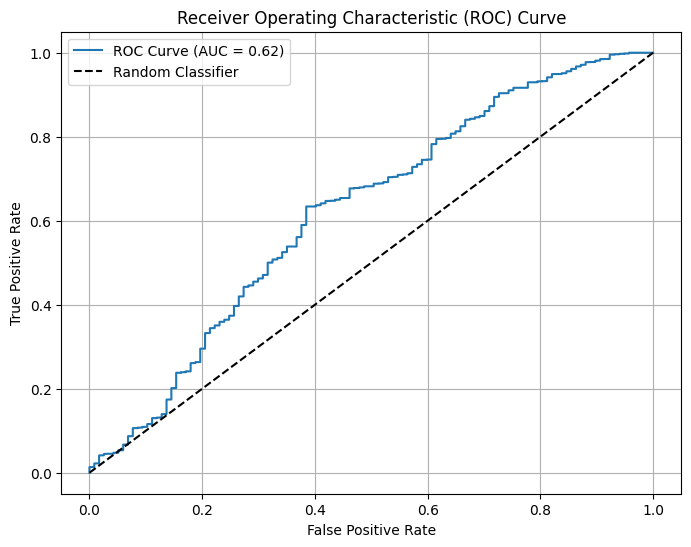

In [117]:
from sklearn.metrics import roc_curve, roc_auc_score

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid(True)
plt.show()

Now, let's look at the Precision-Recall curve. This is particularly useful for imbalanced datasets, like ours, as it shows the trade-off between precision and recall for different thresholds.

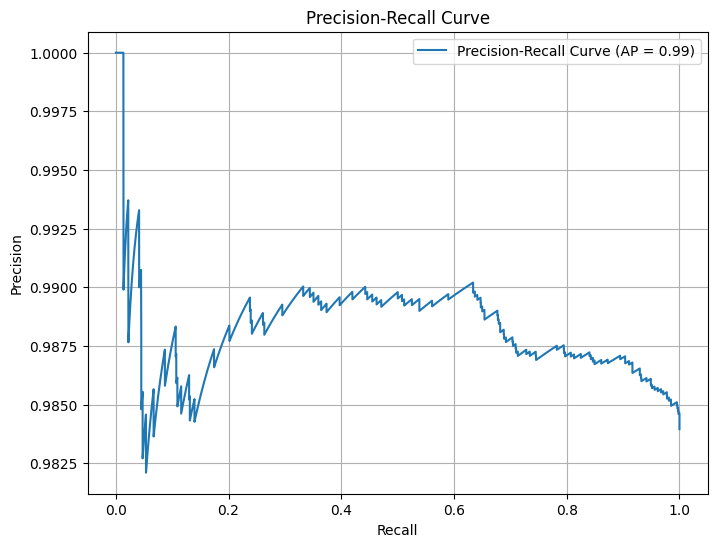

In [118]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Calculate Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)
pr_auc_score = average_precision_score(y_test, y_probs)

# Plot Precision-Recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'Precision-Recall Curve (AP = {pr_auc_score:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.show()